<a href="https://colab.research.google.com/github/Terheer/1-Image-Classifier/blob/main/Image_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import torchvision
from torchvision import transforms
import torchvision.models as models
from torch.utils.data import DataLoader

In [13]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

In [14]:

#Define the transformations
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

#Point to the directories
train_dir = '/content/drive/MyDrive/archive (6)/Dataset/train'
test_dir = '/content/drive/MyDrive/archive (6)/Dataset/train'

#Create Datasets using ImageFolder
train_data = torchvision.datasets.ImageFolder(train_dir, transform=data_transforms)
test_data = torchvision.datasets.ImageFolder(test_dir, transform=data_transforms)

#Create the DataLoaders
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

In [15]:
import os

path = "/content/drive/MyDrive/archive (6)/Dataset"

print(os.path.exists(path))

True


In [16]:
image_extensions = ('.png', '.jpg', '.jpeg')

total_images = 0
for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(image_extensions):
            total_images += 1

print("Total images:", total_images)

Total images: 3582


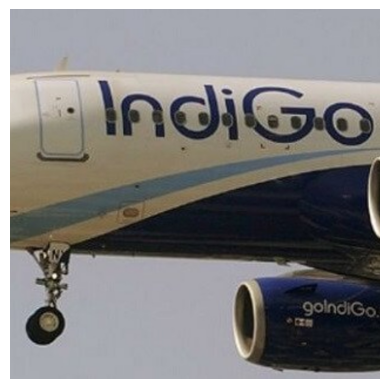

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import random

#Get the list of image paths
image_paths = []

for root, dirs, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_paths.append(os.path.join(root, file))

#Show random images
img = Image.open(random.choice(image_paths))
plt.imshow(img)
plt.axis("off")
plt.show()

In [18]:
image, label = train_data[0]

In [19]:
class_names = ['airplane', 'car','ship']

In [20]:
class NeuralNet(nn.Module):
  def __init__(self):
    super().__init__()

    self.convl = nn.Conv2d(3, 12, 5)
    self.pool = nn.MaxPool2d(2, 2)
    self.conv2 = nn.Conv2d(12, 24, 5)
    self.fc1 = nn.Linear(24 * 53 * 53, 120)
    self.fc2 = nn.Linear(120, 84)
    self.fc3 = nn.Linear(84, 10)

  def forward(self, x):
    x = self.pool(F.relu(self.convl(x)))
    x = self.pool(F.relu(self.conv2(x)))
    x = torch.flatten(x, 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x

In [21]:
net = NeuralNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [22]:
for epoch in range (10):
    print(f'Training epoch {epoch}...')

    running_loss = 0.0

    for i, data in enumerate(train_loader):
        inputs, labels = data

        optimizer.zero_grad()

        outputs = net(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()


    print(f'Loss: {running_loss / len(train_loader):.4f}')

Training epoch 0...
Loss: 1.0637
Training epoch 1...
Loss: 0.6454
Training epoch 2...
Loss: 0.5414
Training epoch 3...
Loss: 0.4871
Training epoch 4...
Loss: 0.4056
Training epoch 5...
Loss: 0.3516
Training epoch 6...
Loss: 0.2809
Training epoch 7...
Loss: 0.2231
Training epoch 8...
Loss: 0.2090
Training epoch 9...
Loss: 0.1564


In [23]:
torch.save(net.state_dict(), 'trained_net.pth')

In [24]:
net = NeuralNet()
net.load_state_dict(torch.load('trained_net.pth'))

<All keys matched successfully>

In [25]:
correct = 0
total = 0

net.eval()

with torch.no_grad():
    for data in test_loader:
        images, labels = data
        outputs = net(images)
        _, prediction = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (prediction == labels).sum().item()

accuracy = 100 * correct / total
print(f'Accuracy: {accuracy:.2f}%')

Accuracy: 95.60%


In [27]:
from prompt_toolkit import output
new_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Changed from (32, 32) to (224, 224) to match training input size
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

def load_image(image_path):
    image = Image.open(image_path)
    image = new_transform(image)
    image = image.unsqueeze(0)
    return image



image_paths =['/content/pexels-asemirski-36366992.jpg','/content/pexels-planespotter-geneva-1877406873-30475503.jpg', '/content/pexels-ellobito01-7128920.jpg']
images = [load_image(path) for path in image_paths]

net.eval()
with torch.no_grad():
  for image in images:
    output = net(image)
    _, predicted = torch.max(output, 1)
    print(f'Prediction: {class_names[predicted.item()]}')

Prediction: car
Prediction: airplane
Prediction: ship
